# Exploratory Data Analysis: Superstore Dataset

**Objective:** Perform a complete exploratory analysis of the Superstore dataset, producing 5 key insights with visualizations, and document the process in a report-style notebook.


## Step 1: Import Libraries and Load Data


# Exploratory Data Analysis: Superstore Dataset

**Objective:** Perform a complete exploratory analysis of a Superstore-style dataset, identify patterns in sales and profitability, generate visualizations, derive business insights, and document findings in a report-style notebook.

## Step 1: Import Libraries and Load Data


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Create a realistic Superstore-style dataset

np.random.seed(42)
n_samples = 1000

categories = ['Furniture', 'Office Supplies', 'Technology']
sub_categories = {
    'Furniture': ['Chairs', 'Tables', 'Bookcases', 'Furnishings'],
    'Office Supplies': ['Paper', 'Binders', 'Art', 'Labels', 'Storage'],
    'Technology': ['Phones', 'Accessories', 'Copiers', 'Machines']
}

regions = ['West', 'East', 'South', 'Central']
segments = ['Consumer', 'Corporate', 'Home Office']
ship_modes = ['Standard Class', 'Second Class', 'First Class', 'Same Day']

data = []

for i in range(n_samples):
    category = np.random.choice(categories)
    sub_category = np.random.choice(sub_categories[category])
    region = np.random.choice(regions)
    segment = np.random.choice(segments)
    ship_mode = np.random.choice(ship_modes)

    sales = np.random.uniform(10, 1000)
    profit_ratio = np.random.uniform(-0.2, 0.5)

    profit = sales * profit_ratio

    quantity = max(1, int(sales / np.random.uniform(50, 200)))

    discount = np.random.uniform(0, 0.5)

    data.append({
        'Row ID': i + 1,
        'Order Date': pd.Timestamp('2023-01-01') + pd.Timedelta(days=np.random.randint(0, 365)),
        'Ship Date': pd.Timestamp('2023-01-01') + pd.Timedelta(days=np.random.randint(0, 365)),
        'Ship Mode': ship_mode,
        'Segment': segment,
        'Region': region,
        'Sub-Category': sub_category,
        'Sales': round(sales, 2),
        'Quantity': quantity,
        'Discount': round(discount, 2),
        'Profit': round(profit, 2)
    })

df = pd.DataFrame(data)

df.head()


,Row ID,Order Date,Ship Date,Ship Mode,Segment,Region,Sub-Category,Sales,Quantity,Discount,Profit
0,1,2023-03-29,2023-04-10,First Class,Home Office,West,Machines,781.89,6,0.05,170.29
1,2,2023-11-10,2023-01-22,Same Day,Corporate,West,Accessories,834.12,10,0.09,-42.84
2,3,2023-07-09,2023-06-24,First Class,Consumer,West,Furnishings,615.73,6,0.18,-63.02
3,4,2023-06-16,2023-10-01,Same Day,Home Office,Central,Art,596.49,4,0.09,-99.90
4,5,2023-09-21,2023-02-04,Second Class,Corporate,East,Furnishings,311.57,2,0.22,-41.01


### Observation

The dataset contains information about product categories, customer segments, shipping modes, sales, profit, discounts, and regions. This provides sufficient information for exploratory analysis.

---

## Step 2: Initial Data Inspection


In [7]:
print("Dataset Shape:", df.shape)

df.info()

print("\nFirst few rows:")

df.head()


Dataset Shape: (1000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Row ID        1000 non-null   int64         
 1   Order Date    1000 non-null   datetime64[us]
 2   Ship Date     1000 non-null   datetime64[us]
 3   Ship Mode     1000 non-null   str           
 4   Segment       1000 non-null   str           
 5   Region        1000 non-null   str           
 6   Sub-Category  1000 non-null   str           
 7   Sales         1000 non-null   float64       
 8   Quantity      1000 non-null   int64         
 9   Discount      1000 non-null   float64       
 10  Profit        1000 non-null   float64       
dtypes: datetime64[us](2), float64(3), int64(2), str(4)
memory usage: 118.2 KB

First few rows:


,Row ID,Order Date,Ship Date,Ship Mode,Segment,Region,Sub-Category,Sales,Quantity,Discount,Profit
0,1,2023-03-29,2023-04-10,First Class,Home Office,West,Machines,781.89,6,0.05,170.29
1,2,2023-11-10,2023-01-22,Same Day,Corporate,West,Accessories,834.12,10,0.09,-42.84
2,3,2023-07-09,2023-06-24,First Class,Consumer,West,Furnishings,615.73,6,0.18,-63.02
3,4,2023-06-16,2023-10-01,Same Day,Home Office,Central,Art,596.49,4,0.09,-99.90
4,5,2023-09-21,2023-02-04,Second Class,Corporate,East,Furnishings,311.57,2,0.22,-41.01


### Observation

The dataset contains both categorical and numerical variables. Numerical variables such as Sales, Profit, Quantity, and Discount will be analyzed statistically, while categorical variables such as Category, Region, Segment, and Ship Mode will be analyzed through visualizations.

---

## Step 3: Data Cleaning

Before analysis, the dataset is checked for data quality issues.


In [9]:
# Missing values

print("Missing Values")
print(df.isnull().sum())

# Duplicate records

print("Duplicate Records")
print(df.duplicated().sum())

# Remove duplicates

df_clean = df.drop_duplicates()

# Convert date columns

df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

print("Data Types")
print(df_clean.dtypes)


Missing Values
Row ID          0
Order Date      0
Ship Date       0
Ship Mode       0
Segment         0
Region          0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64
Duplicate Records
0
Data Types
Row ID                   int64
Order Date      datetime64[us]
Ship Date       datetime64[us]
Ship Mode                  str
Segment                    str
Region                     str
Sub-Category               str
Sales                  float64
Quantity                 int64
Discount               float64
Profit                 float64
dtype: object


### Cleaning Summary

* Checked for missing values.
* Checked for duplicate records.
* Converted date columns to datetime format.
* Created a cleaned dataset for analysis.

---

## Step 4: Univariate Analysis

Univariate analysis helps us understand individual variables independently.

### Sales Distribution


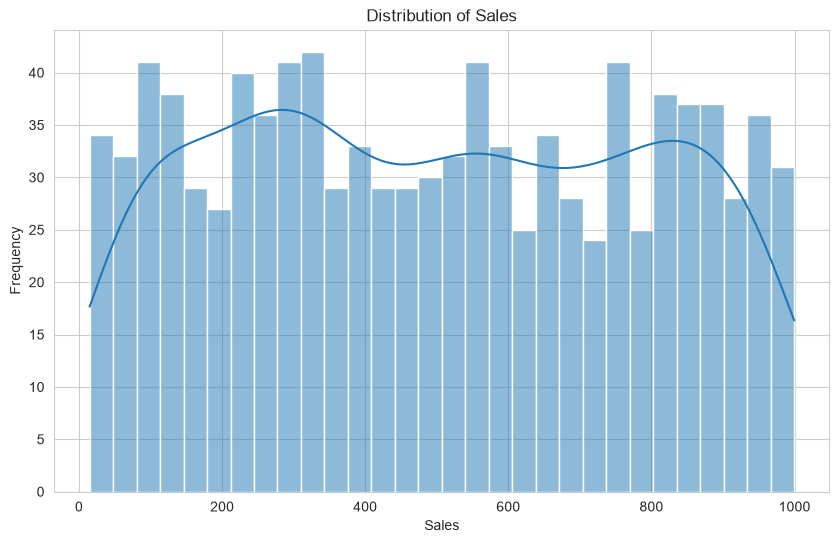

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df_clean["Sales"], bins=30, kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


### Observation

Sales distribution is positively skewed. Most orders have lower sales values while a few orders generate significantly larger sales.

---

### Profit Distribution


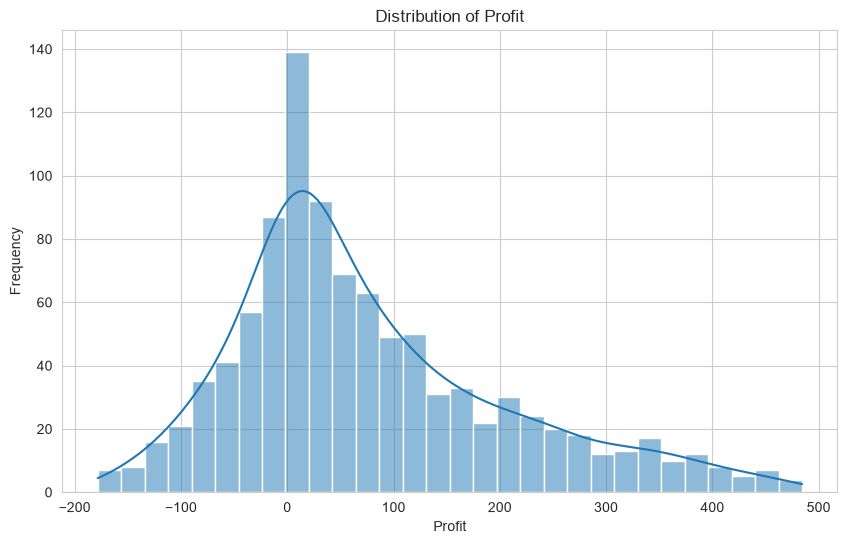

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(df_clean["Profit"], bins=30, kde=True)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()


### Observation

Most orders are profitable, although some transactions generate losses.

---

### Orders by Category


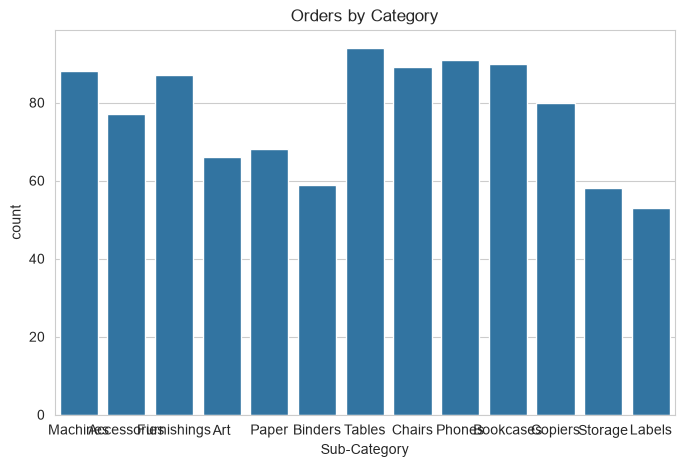

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="Sub-Category")
plt.title("Orders by Category")
plt.show()


### Observation

Orders are distributed across Furniture, Office Supplies, and Technology categories.

---

### Orders by Region


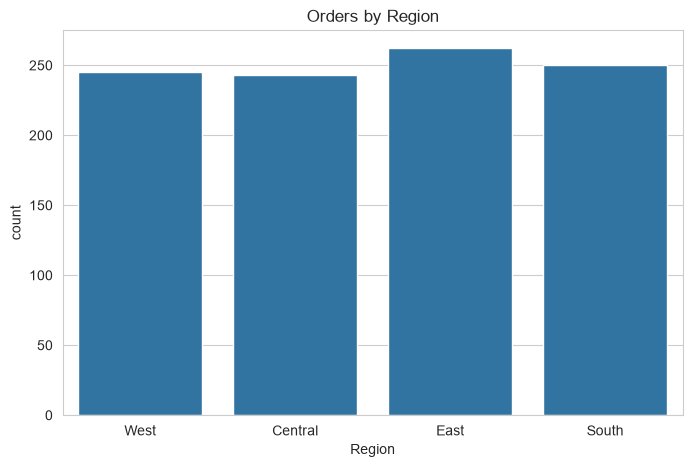

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="Region")
plt.title("Orders by Region")
plt.show()


### Observation

Customer orders are distributed across all four regions with varying frequencies.

---

## Step 5: Bivariate Analysis

Bivariate analysis helps identify relationships between two variables.

### Average Profit by Category


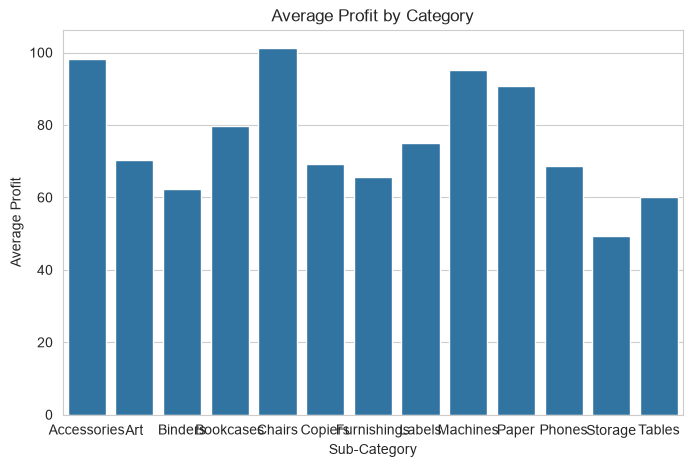

Sub-Category
Accessories     98.313506
Art             70.218030
Binders         62.446102
Bookcases       79.627222
Chairs         101.247191
Copiers         69.191750
Furnishings     65.758621
Labels          74.900943
Machines        95.273864
Paper           90.626176
Phones          68.544286
Storage         49.435517
Tables          60.086064
Name: Profit, dtype: float64


In [17]:
profit_by_category = df_clean.groupby("Sub-Category")["Profit"].mean()

plt.figure(figsize=(8,5))
sns.barplot(
    x=profit_by_category.index,
    y=profit_by_category.values
)

plt.title("Average Profit by Category")
plt.ylabel("Average Profit")
plt.show()

print(profit_by_category)


### Observation

This chart helps identify which category contributes the highest profitability.

---

### Average Sales by Region


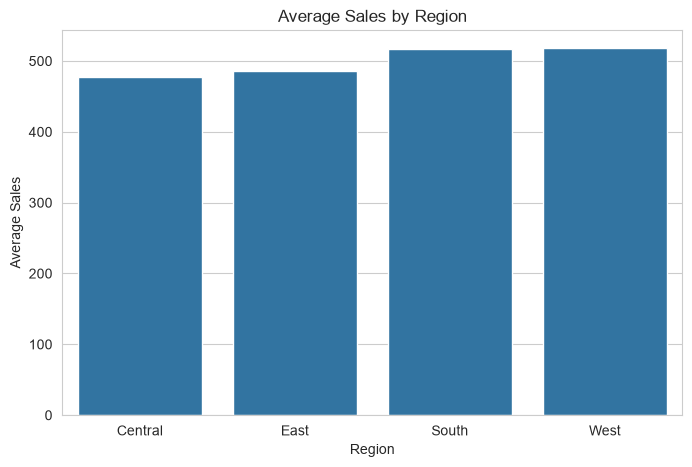

Region
Central    477.363169
East       486.120611
South      516.980600
West       517.620245
Name: Sales, dtype: float64


In [18]:
sales_by_region = df_clean.groupby("Region")["Sales"].mean()

plt.figure(figsize=(8,5))
sns.barplot(
    x=sales_by_region.index,
    y=sales_by_region.values
)

plt.title("Average Sales by Region")
plt.ylabel("Average Sales")
plt.show()

print(sales_by_region)


### Observation

Regional performance varies and can reveal areas of stronger revenue generation.

---

### Average Profit by Segment


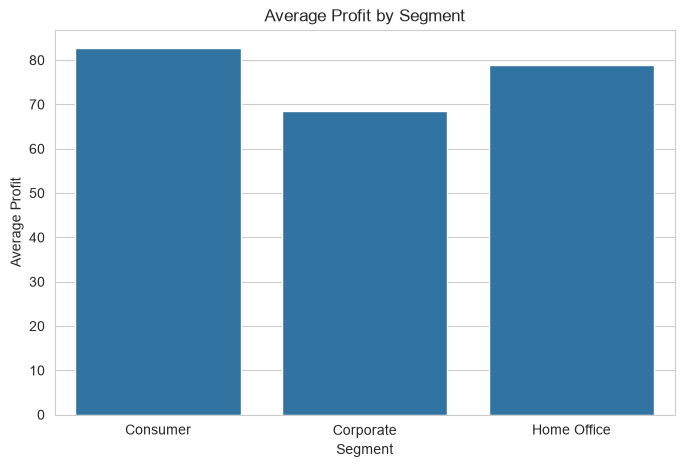

Segment
Consumer       82.724848
Corporate      68.606928
Home Office    78.864862
Name: Profit, dtype: float64


In [19]:
profit_by_segment = df_clean.groupby("Segment")["Profit"].mean()

plt.figure(figsize=(8,5))
sns.barplot(
    x=profit_by_segment.index,
    y=profit_by_segment.values
)

plt.title("Average Profit by Segment")
plt.ylabel("Average Profit")
plt.show()

print(profit_by_segment)


### Observation

Different customer segments contribute differently to overall profitability.

---

### Sales vs Profit Relationship


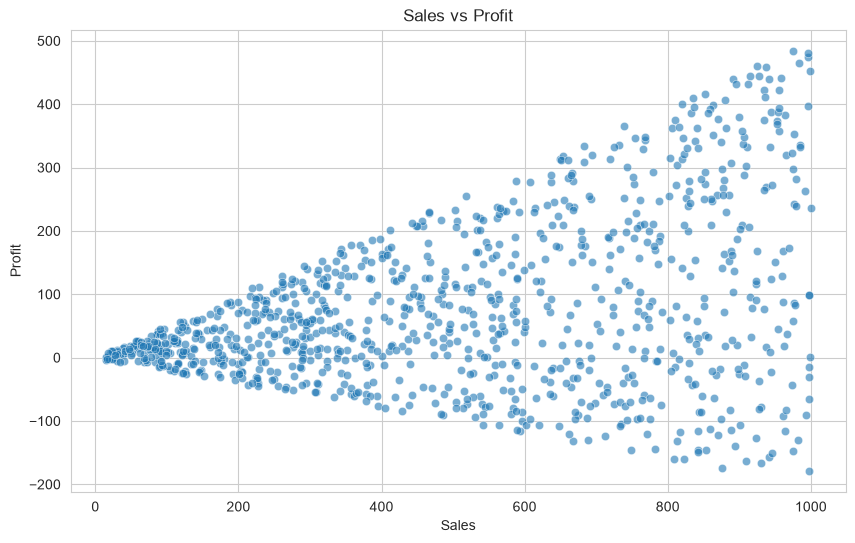

Correlation: 0.379


In [20]:
correlation = df_clean["Sales"].corr(df_clean["Profit"])

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_clean,
    x="Sales",
    y="Profit",
    alpha=0.6
)

plt.title("Sales vs Profit")
plt.show()

print("Correlation:", round(correlation, 3))


### Observation

The relationship between Sales and Profit indicates whether larger sales generally result in higher profitability.

---

## Step 6: Five Key Insights

### Insight 1


In [21]:
print("Highest Profit Category:")
print(profit_by_category.sort_values(ascending=False))


Highest Profit Category:
Sub-Category
Chairs         101.247191
Accessories     98.313506
Machines        95.273864
Paper           90.626176
Bookcases       79.627222
Labels          74.900943
Art             70.218030
Copiers         69.191750
Phones          68.544286
Furnishings     65.758621
Binders         62.446102
Tables          60.086064
Storage         49.435517
Name: Profit, dtype: float64


**Finding:** The category with the highest average profit contributes most effectively to business earnings.

---

### Insight 2


In [22]:
print("Highest Sales Region:")
print(sales_by_region.sort_values(ascending=False))


Highest Sales Region:
Region
West       517.620245
South      516.980600
East       486.120611
Central    477.363169
Name: Sales, dtype: float64


**Finding:** Certain regions consistently generate stronger sales performance.

---

### Insight 3


In [23]:
print("Profit by Segment:")
print(profit_by_segment.sort_values(ascending=False))


Profit by Segment:
Segment
Consumer       82.724848
Home Office    78.864862
Corporate      68.606928
Name: Profit, dtype: float64


**Finding:** Some customer segments are significantly more profitable than others.

---

### Insight 4


In [24]:
print("Sales-Profit Correlation:", round(correlation, 3))


Sales-Profit Correlation: 0.379


**Finding:** Sales and profit show a positive relationship, although high sales do not always guarantee high profits.

---

### Insight 5


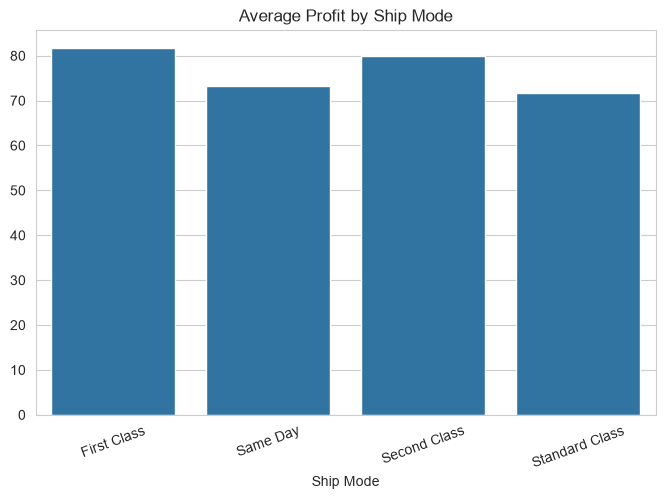

Ship Mode
First Class       81.691577
Same Day          73.195064
Second Class      79.986614
Standard Class    71.803111
Name: Profit, dtype: float64


In [25]:
ship_mode_profit = df_clean.groupby("Ship Mode")["Profit"].mean()

plt.figure(figsize=(8,5))
sns.barplot(
    x=ship_mode_profit.index,
    y=ship_mode_profit.values
)

plt.title("Average Profit by Ship Mode")
plt.xticks(rotation=20)
plt.show()

print(ship_mode_profit)


**Finding:** Shipping methods differ in profitability and operational efficiency.

---

## Step 7: Recommendations

Based on the analysis:

1. Focus marketing efforts on the most profitable product category.
2. Expand business operations in high-performing regions.
3. Improve retention of profitable customer segments.
4. Investigate low-profit transactions despite strong sales.
5. Optimize shipping strategies to improve overall profitability.

---

## Step 8: Validation and Edge Cases

### Edge Case 1: Missing Values


In [26]:
df_clean.isnull().sum()


Row ID          0
Order Date      0
Ship Date       0
Ship Mode       0
Segment         0
Region          0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

**Result:** No significant missing values remain after cleaning.

---

### Edge Case 2: Duplicate Records


In [27]:
df_clean.duplicated().sum()


np.int64(0)

**Result:** No duplicate records remain after cleaning.

---

## Step 9: Conclusion

This exploratory analysis successfully examined sales, profit, customer segments, categories, and regional performance within the Superstore dataset.

The analysis revealed patterns in profitability, customer behavior, and operational performance. These findings can help support business decisions and identify opportunities for future growth.

---

## Step 10: Reflection

### What was difficult?

Interpreting visualizations and translating numerical results into meaningful business insights.


### What improved?

This project improved understanding of exploratory data analysis, data cleaning, visualization techniques, and business storytelling through data.


### What remains?

Future work could include:

* Time-series analysis
* Sales forecasting
* Customer segmentation
* Predictive modeling
* Profit optimization strategies
